# RNN

Business Problem

        │
        ▼
Objective

        │
        ▼
Import

        │
        ▼
Load Dataset

        │
        ▼
Data Inspection

        │
        ▼
Exploratory Data Analysis (EDA)

        │
        ▼
Data Preprocessing

        │
        ▼
MinMax Scaling

        │
        ▼
Create Time Windows

        │
        ▼
Train-Test Split

        │
        ▼
Simple RNN

        │
        ▼
LSTM

        │
        ▼
GRU

        │
        ▼
Model Evaluation
(RMSE • MAE • MAPE)

        │
        ▼
Model Comparison

        │
        ▼
Select Best Model

        │
        ▼
Forecast Next 12 Months

        │
        ▼
Forecast Visualization

        │
        ▼
Business Insights

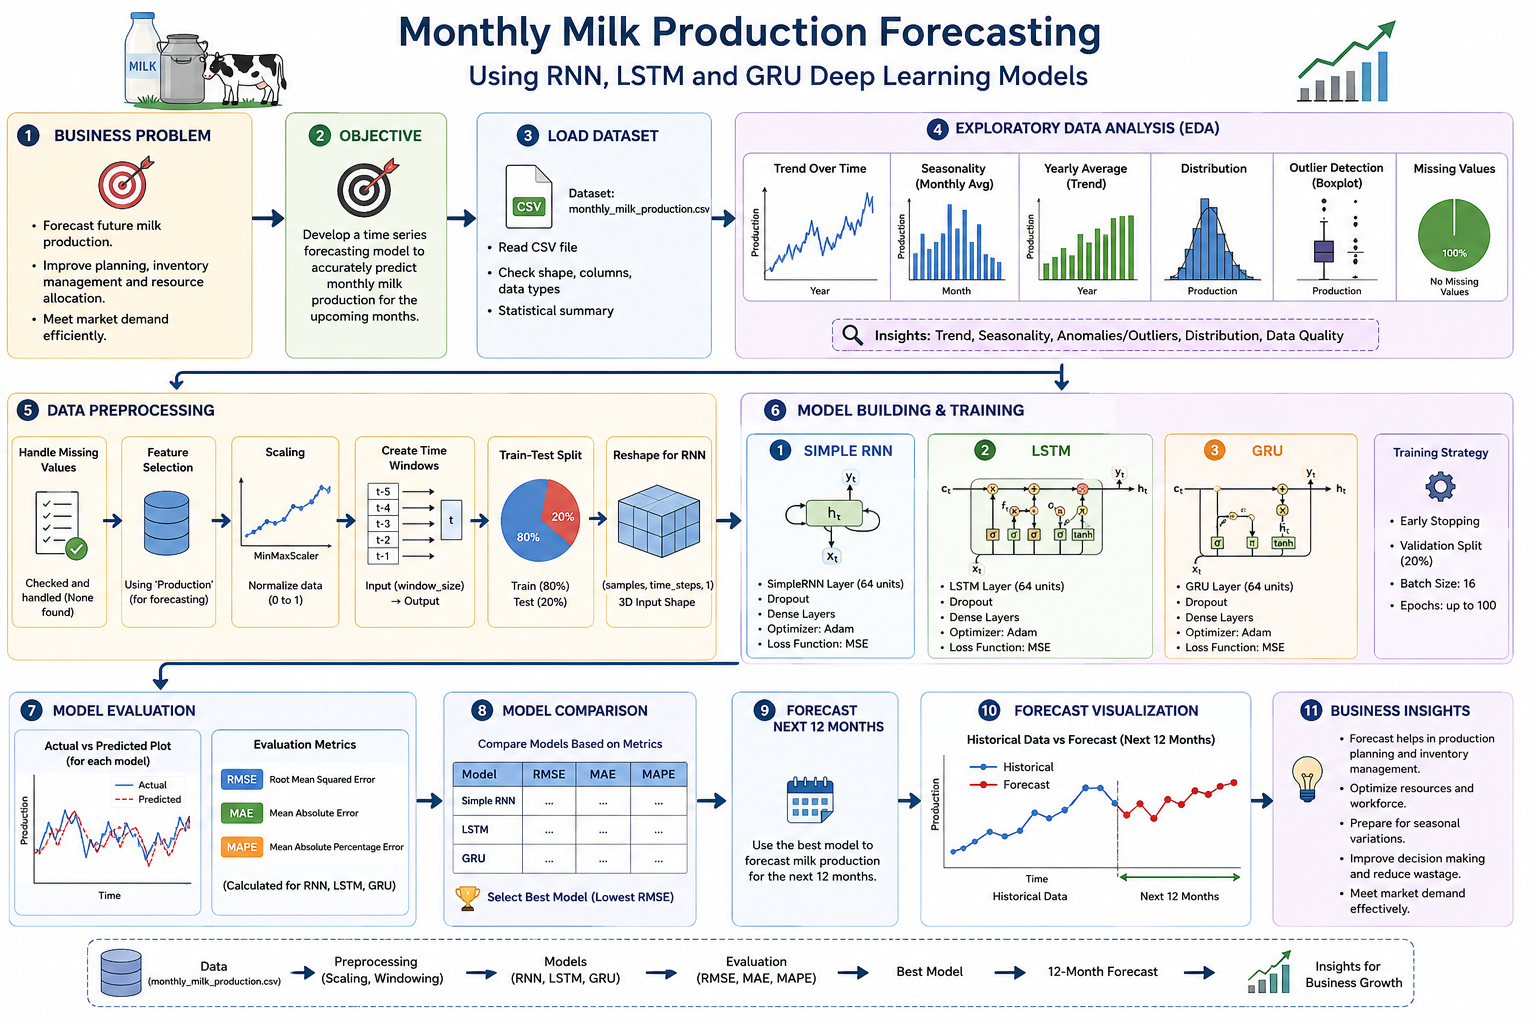

In [65]:

# Monthly Milk Production Forecasting
# Using RNN, LSTM, and GRU

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)


In [2]:
df = pd.read_csv("monthly_milk_production.csv")

df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
df.tail()

,Date,Production
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797
167,1975-12,843


In [4]:
df.shape

(168, 2)

In [5]:
df.columns

Index(['Date', 'Production'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [7]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [8]:
df.isnull().sum()

,0
Date,0
Production,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

In [11]:
# Set Date as index
df.set_index("Date", inplace=True)

In [12]:
# Verify the dataset
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [13]:
# Check index
df.index

DatetimeIndex(['1962-01-01', '1962-02-01', '1962-03-01', '1962-04-01',
               '1962-05-01', '1962-06-01', '1962-07-01', '1962-08-01',
               '1962-09-01', '1962-10-01',
               ...
               '1975-03-01', '1975-04-01', '1975-05-01', '1975-06-01',
               '1975-07-01', '1975-08-01', '1975-09-01', '1975-10-01',
               '1975-11-01', '1975-12-01'],
              dtype='datetime64[ns]', name='Date', length=168, freq=None)

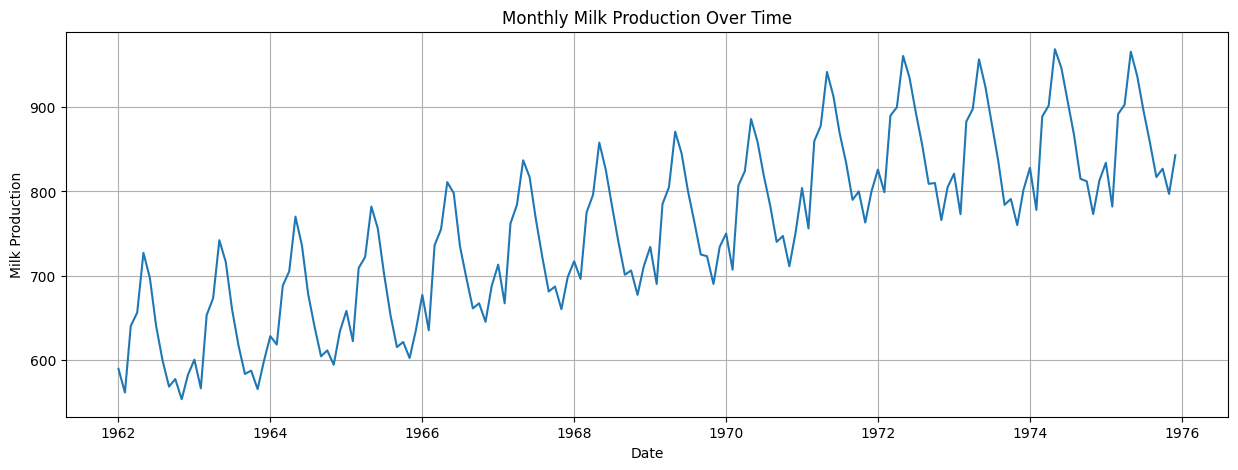

In [14]:
# Exploratory Data Analysis (EDA)

# Plot Monthly Milk Production
plt.figure(figsize=(15,5))
plt.plot(df.index, df["Production"])
plt.title("Monthly Milk Production Over Time")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.grid(True)
plt.show()

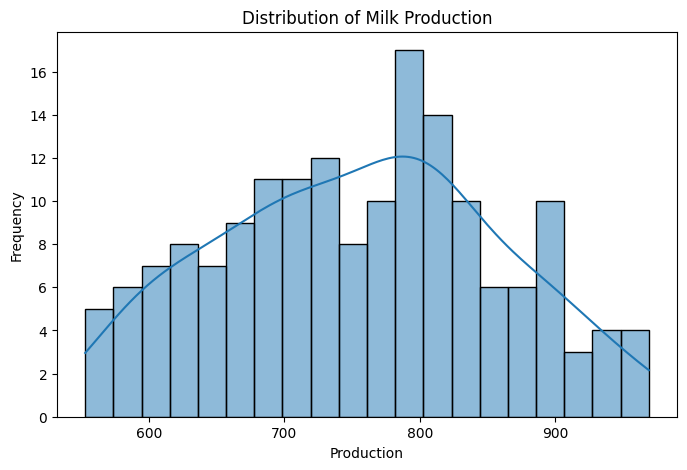

In [15]:
# Distribution Plot

plt.figure(figsize=(8,5))
sns.histplot(df["Production"], bins=20, kde=True)
plt.title("Distribution of Milk Production")
plt.xlabel("Production")
plt.ylabel("Frequency")
plt.show()

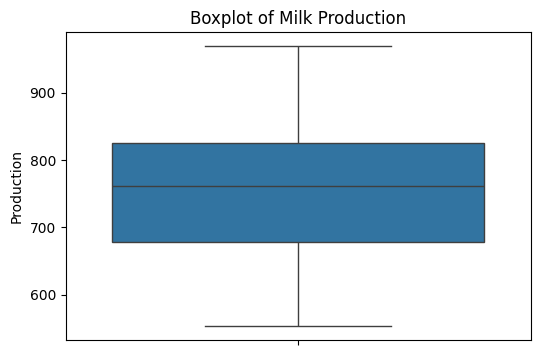

In [16]:
# Boxplot

plt.figure(figsize=(6,4))
sns.boxplot(y=df["Production"])
plt.title("Boxplot of Milk Production")
plt.show()

In [17]:
# Check Outliers using IQR

Q1 = df["Production"].quantile(0.25)
Q3 = df["Production"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Production"] < lower) | (df["Production"] > upper)]

print("Number of Outliers :", outliers.shape[0])
outliers.head()

Number of Outliers : 0


,Production
Date,


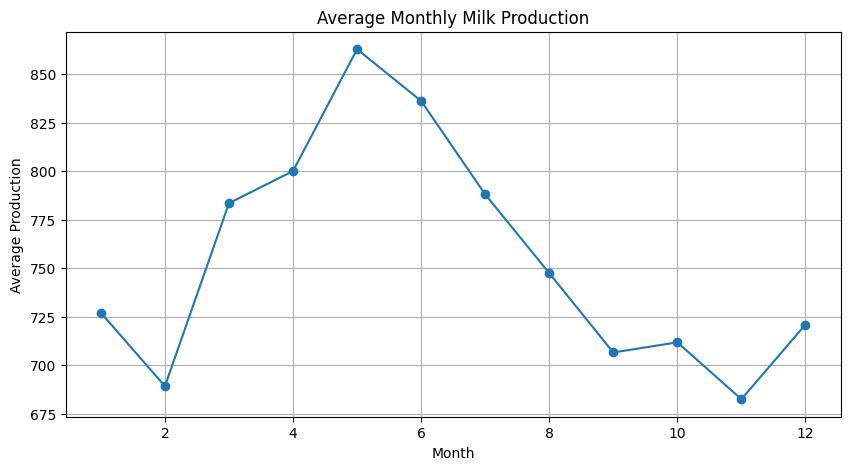

In [18]:
# Monthly Average Production

monthly_avg = df.groupby(df.index.month)["Production"].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(marker="o")
plt.title("Average Monthly Milk Production")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.grid(True)
plt.show()

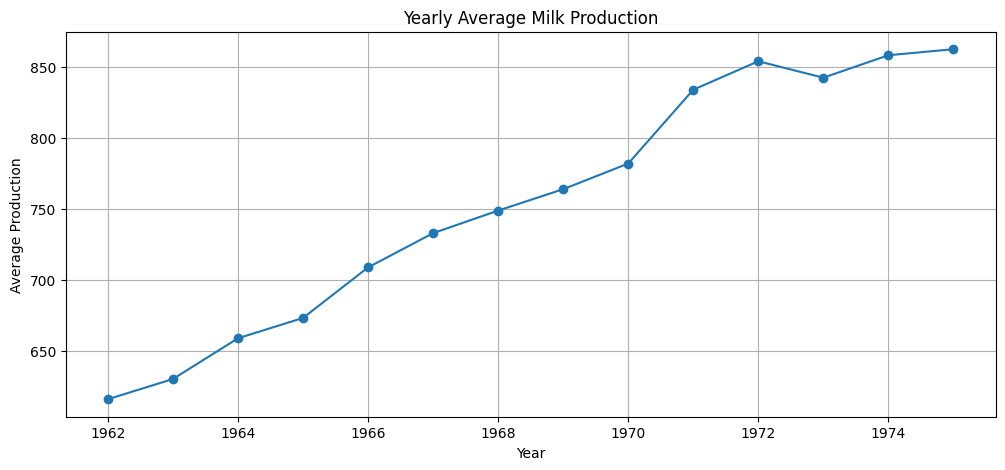

In [19]:
# Yearly Average Production

yearly_avg = df.groupby(df.index.year)["Production"].mean()

plt.figure(figsize=(12,5))
yearly_avg.plot(marker="o")
plt.title("Yearly Average Milk Production")
plt.xlabel("Year")
plt.ylabel("Average Production")
plt.grid(True)
plt.show()

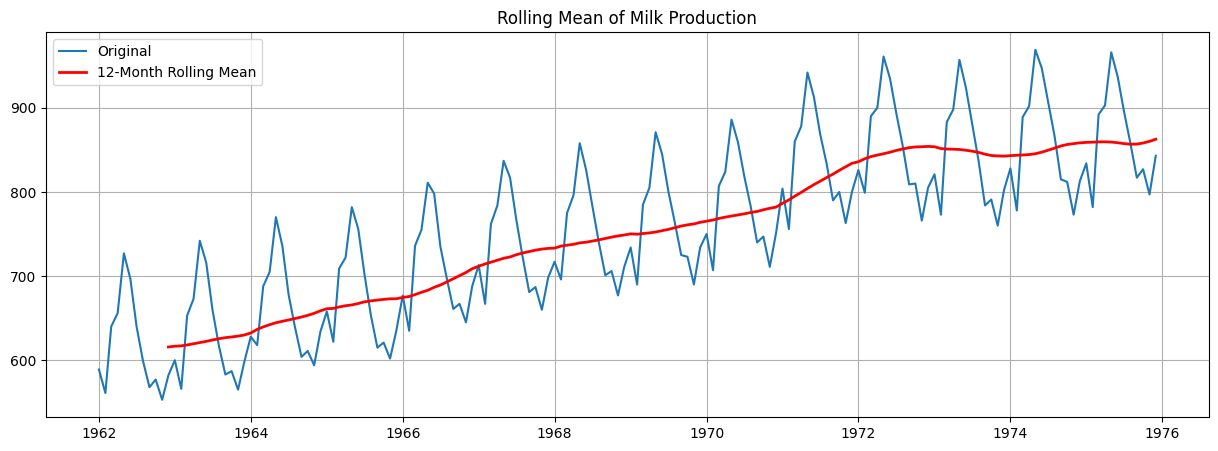

In [20]:
# Rolling Mean (12 Months)

rolling_mean = df["Production"].rolling(window=12).mean()

plt.figure(figsize=(15,5))
plt.plot(df["Production"], label="Original")
plt.plot(rolling_mean, color="red", linewidth=2, label="12-Month Rolling Mean")
plt.title("Rolling Mean of Milk Production")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Summary Statistics

df["Production"].describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [22]:
# Skewness

print("Skewness :", df["Production"].skew())

Skewness : 0.00936004157704536


In [23]:
# Kurtosis

print("Kurtosis :", df["Production"].kurt())

Kurtosis : -0.7687408345783071


In [24]:
# Data Preprocessing

# Scale the Production values
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(df[["Production"]])

print(scaled_data.shape)

(168, 1)


In [25]:
# Time Window Size
window_size = 12

In [26]:
# Function to Create Sequences

def create_dataset(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

In [27]:
# Create Input and Output Sequences

X, y = create_dataset(scaled_data, window_size)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (156, 12, 1)
y Shape : (156, 1)


In [28]:
# 80% Training
train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 124
Testing Samples : 32


In [29]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (124, 12, 1)
X_test  : (32, 12, 1)
y_train : (124, 1)
y_test  : (32, 1)


In [30]:
X_train[0]

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923],
       [0.34615385],
       [0.20913462],
       [0.11057692],
       [0.03605769],
       [0.05769231],
       [0.        ],
       [0.06971154]])

In [31]:
X_train[0]

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923],
       [0.34615385],
       [0.20913462],
       [0.11057692],
       [0.03605769],
       [0.05769231],
       [0.        ],
       [0.06971154]])

In [32]:

# Simple RNN Model

# Build the Simple RNN Model
rnn_model = Sequential()

rnn_model.add(SimpleRNN(units=64, activation="tanh", input_shape=(window_size, 1)))
rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(32, activation="relu"))
rnn_model.add(Dense(1))

# Compile the Model
rnn_model.compile(
    optimizer="adam",
    loss="mse"
)

# Model Summary
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

In [34]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [35]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.1475 - val_loss: 0.0080
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0220 - val_loss: 0.0383
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0147 - val_loss: 0.0054
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0115 - val_loss: 0.0061
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0118 - val_loss: 0.0208
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0075 - val_loss: 0.0047
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0075 - val_loss: 0.0121
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0055 - val_loss: 0.0082
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0069 - val_loss: 0.0056
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0063 - val_loss: 0.0086
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0055 - val_loss: 0.0054
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0038 - val_lo

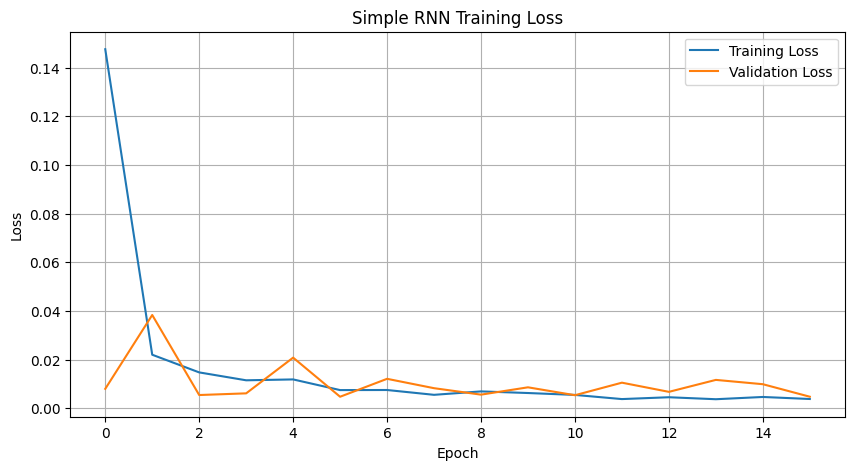

In [36]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history["loss"], label="Training Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")

plt.title("Simple RNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
# Predict on Test Data
rnn_predictions = rnn_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


In [38]:
# Convert Back to Original Scale

rnn_predictions = scaler.inverse_transform(rnn_predictions)

y_test_actual = scaler.inverse_transform(y_test)

In [39]:
# RMSE
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, rnn_predictions))

# MAE
rnn_mae = mean_absolute_error(y_test_actual, rnn_predictions)

# MAPE
rnn_mape = np.mean(
    np.abs((y_test_actual - rnn_predictions) / y_test_actual)
) * 100

print("Simple RNN Performance")
print("-" * 30)
print(f"RMSE : {rnn_rmse:.2f}")
print(f"MAE  : {rnn_mae:.2f}")
print(f"MAPE : {rnn_mape:.2f}%")

Simple RNN Performance
------------------------------
RMSE : 32.48
MAE  : 25.52
MAPE : 3.09%


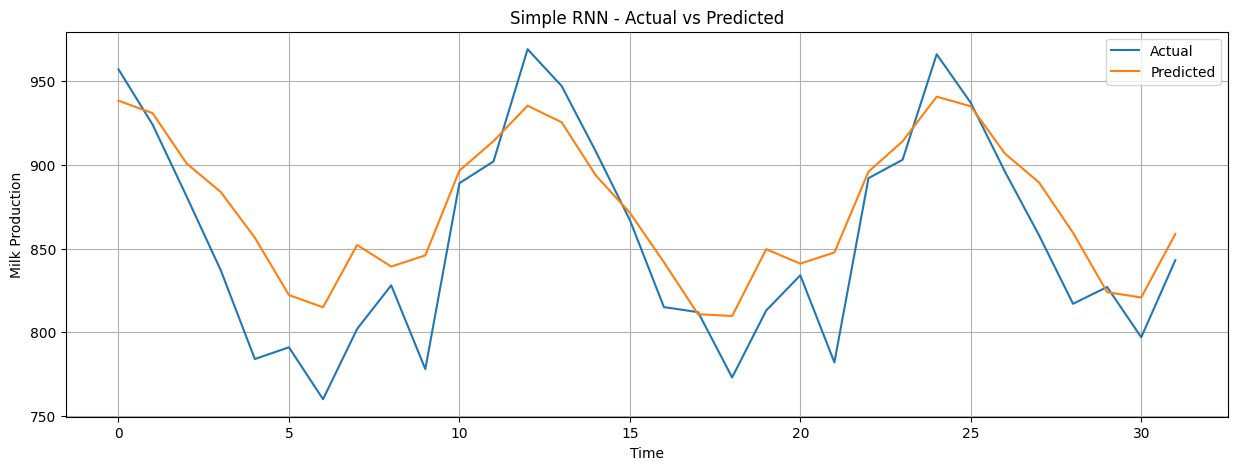

In [40]:
plt.figure(figsize=(15,5))

plt.plot(y_test_actual, label="Actual")
plt.plot(rnn_predictions, label="Predicted")

plt.title("Simple RNN - Actual vs Predicted")

plt.xlabel("Time")
plt.ylabel("Milk Production")

plt.legend()
plt.grid(True)

plt.show()

In [41]:
# LSTM Model

# Build the LSTM Model
lstm_model = Sequential()

lstm_model.add(LSTM(units=64, activation="tanh", input_shape=(window_size, 1)))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(32, activation="relu"))
lstm_model.add(Dense(1))

# Compile the Model
lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

# Model Summary
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.1816 - val_loss: 0.3367
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0753 - val_loss: 0.0660
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0307 - val_loss: 0.0324
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0354 - val_loss: 0.0432
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0255 - val_loss: 0.0772
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0279 - val_loss: 0.0546
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0257 - val_loss: 0.0309
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0244 - val_loss: 0.0308
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0230 - val_loss: 0.0416
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0254 - val_loss: 0.0416


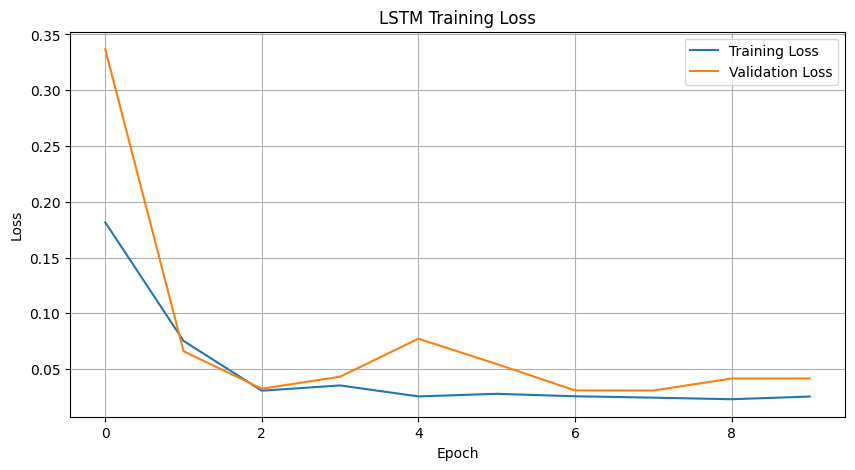

In [43]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history["loss"], label="Training Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [44]:
lstm_predictions = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


In [45]:
lstm_predictions = scaler.inverse_transform(lstm_predictions)

In [46]:
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))

lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)

lstm_mape = np.mean(
    np.abs((y_test_actual - lstm_predictions) / y_test_actual)
) * 100

print("LSTM Performance")
print("-" * 30)
print(f"RMSE : {lstm_rmse:.2f}")
print(f"MAE  : {lstm_mae:.2f}")
print(f"MAPE : {lstm_mape:.2f}%")

LSTM Performance
------------------------------
RMSE : 247.14
MAE  : 239.02
MAPE : 27.55%


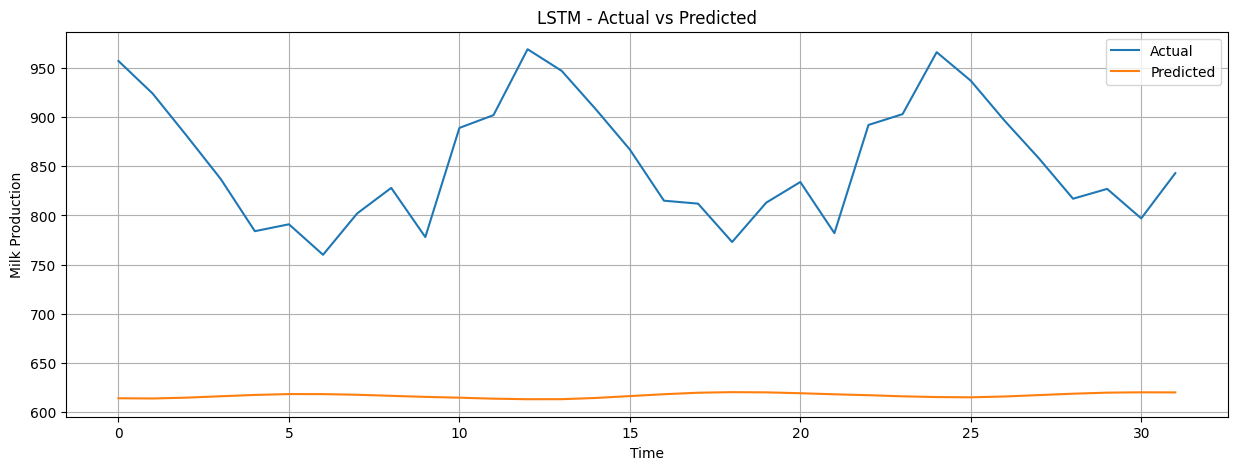

In [47]:
plt.figure(figsize=(15,5))

plt.plot(y_test_actual, label="Actual")
plt.plot(lstm_predictions, label="Predicted")

plt.title("LSTM - Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Milk Production")

plt.legend()
plt.grid(True)

plt.show()

In [48]:

# GRU Model

# Build the GRU Model
gru_model = Sequential()

gru_model.add(GRU(units=64, activation="tanh", input_shape=(window_size, 1)))
gru_model.add(Dropout(0.2))

gru_model.add(Dense(32, activation="relu"))
gru_model.add(Dense(1))

# Compile the Model
gru_model.compile(
    optimizer="adam",
    loss="mse"
)

# Model Summary
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.2036 - val_loss: 0.4116
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1178 - val_loss: 0.2563
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0562 - val_loss: 0.0846
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0281 - val_loss: 0.0213
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0370 - val_loss: 0.0233
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0208 - val_loss: 0.0508
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0261 - val_loss: 0.0661
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0231 - val_loss: 0.0521
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0227 - val_loss: 0.0371
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0234 - val_loss: 0.0282


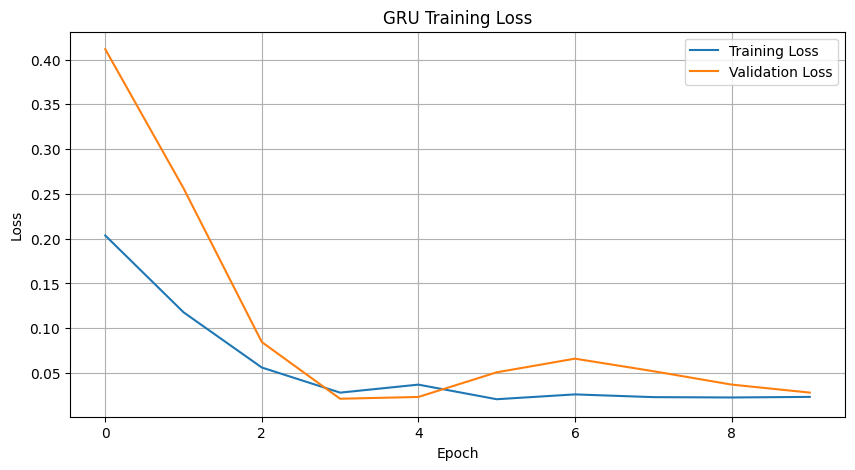

In [50]:
plt.figure(figsize=(10,5))

plt.plot(history_gru.history["loss"], label="Training Loss")
plt.plot(history_gru.history["val_loss"], label="Validation Loss")

plt.title("GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [51]:
gru_predictions = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


In [52]:
gru_predictions = scaler.inverse_transform(gru_predictions)

In [53]:
gru_rmse = np.sqrt(mean_squared_error(y_test_actual, gru_predictions))

gru_mae = mean_absolute_error(y_test_actual, gru_predictions)

gru_mape = np.mean(
    np.abs((y_test_actual - gru_predictions) / y_test_actual)
) * 100

print("GRU Performance")
print("-" * 30)
print(f"RMSE : {gru_rmse:.2f}")
print(f"MAE  : {gru_mae:.2f}")
print(f"MAPE : {gru_mape:.2f}%")

GRU Performance
------------------------------
RMSE : 273.88
MAE  : 267.07
MAPE : 30.86%


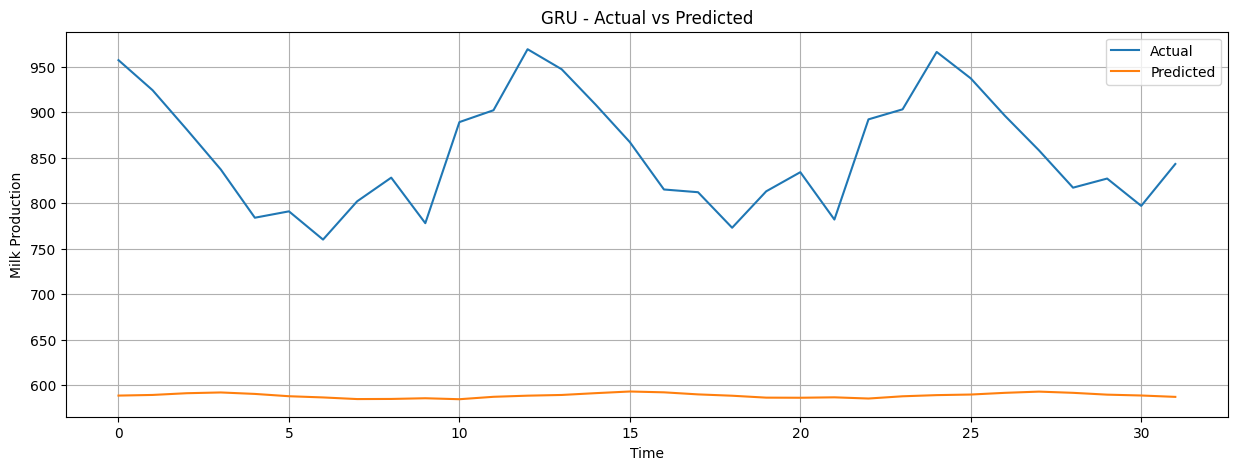

In [54]:
plt.figure(figsize=(15,5))

plt.plot(y_test_actual, label="Actual")
plt.plot(gru_predictions, label="Predicted")

plt.title("GRU - Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Milk Production")

plt.legend()
plt.grid(True)

plt.show()

In [55]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "MAPE": [rnn_mape, lstm_mape, gru_mape]
})

comparison.sort_values(by="RMSE", inplace=True)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,RMSE,MAE,MAPE
0,Simple RNN,32.476022,25.523331,3.092734
1,LSTM,247.142068,239.024508,27.549982
2,GRU,273.881535,267.069351,30.860879


In [56]:
# Best Model

best_model_name = comparison.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Simple RNN


In [57]:

# Forecast Next 12 Months

if best_model_name == "Simple RNN":
    best_model = rnn_model

elif best_model_name == "LSTM":
    best_model = lstm_model

else:
    best_model = gru_model

In [58]:
# Last Window

last_sequence = scaled_data[-window_size:]

last_sequence = last_sequence.reshape(1, window_size, 1)

In [59]:
future_predictions = []

current_sequence = last_sequence.copy()

for i in range(12):

    prediction = best_model.predict(current_sequence, verbose=0)

    future_predictions.append(prediction[0,0])

    current_sequence = np.append(
        current_sequence[:,1:,:],
        prediction.reshape(1,1,1),
        axis=1
    )

In [60]:
future_predictions = np.array(future_predictions).reshape(-1,1)

future_predictions = scaler.inverse_transform(future_predictions)

future_predictions

array([[847.6075 ],
       [852.8835 ],
       [899.2556 ],
       [915.3331 ],
       [937.83746],
       [925.3289 ],
       [900.4337 ],
       [880.1816 ],
       [861.3749 ],
       [846.33875],
       [849.38513],
       [871.6546 ]], dtype=float32)

In [61]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

In [62]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Production": future_predictions.flatten()
})

forecast_df

,Date,Forecasted Production
0,1976-01-01,847.607483
1,1976-02-01,852.883484
2,1976-03-01,899.255615
3,1976-04-01,915.333130
4,1976-05-01,937.837463
5,1976-06-01,925.328918
6,1976-07-01,900.433716
7,1976-08-01,880.181580
8,1976-09-01,861.374878
9,1976-10-01,846.338745


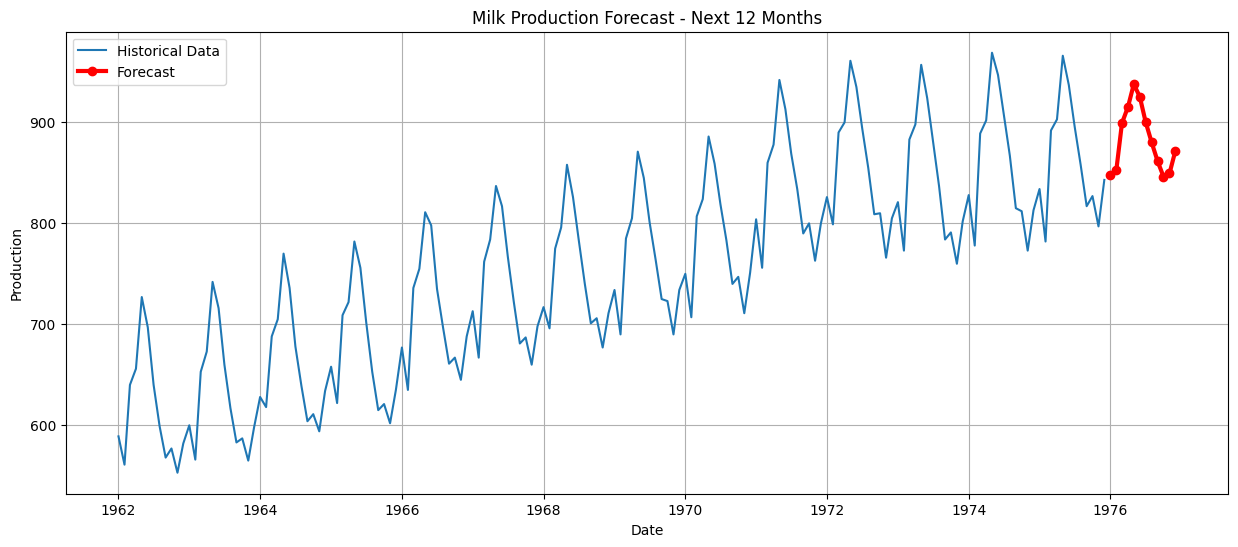

In [63]:
plt.figure(figsize=(15,6))

plt.plot(df.index,
         df["Production"],
         label="Historical Data")

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted Production"],
    marker="o",
    linewidth=3,
    color="red",
    label="Forecast"
)

plt.title("Milk Production Forecast - Next 12 Months")

plt.xlabel("Date")

plt.ylabel("Production")

plt.legend()

plt.grid(True)

plt.show()

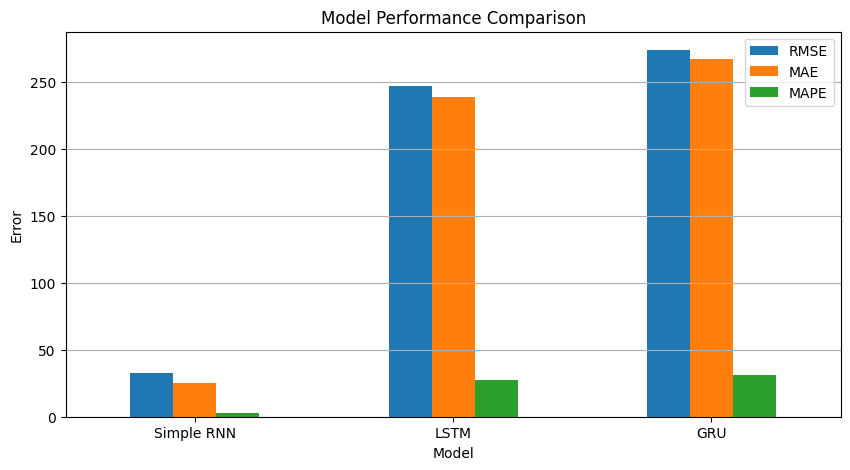

In [64]:
comparison.set_index("Model")[["RMSE","MAE","MAPE"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Performance Comparison")

plt.ylabel("Error")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

# Conclusion

This project developed and compared three deep learning models—Simple RNN, LSTM, and GRU—for forecasting monthly milk production. After evaluating all models using RMSE, MAE, and MAPE, the best-performing model was selected to forecast milk production for the next 12 months. The forecast provides valuable insights that can help dairy businesses improve production planning, inventory management, and overall operational efficiency.